# Analyze Simulation Data

In order to analyze the data for a simulation we must access the Digital Twin's database via our Django settings.
The next cell initializes SQLAlchemy's engine to connect to the Digital Twin's database.
In turn, Pandas will use SQLAlchemy to load data.

In [1]:
import os

import pandas as pd
from sqlalchemy import create_engine
from django.conf import settings

SIMULATION_ID=20

os.environ["DJANGO_SETTINGS_MODULE"] = "twin4dem.settings"
db = settings.DATABASES["default"]
engine = create_engine(
    f"postgresql://{db['USER']}:{db['PASSWORD']}@{db['HOST']}:{db['PORT']}/{db['NAME']}"
)

The next thing to do is load the data we want to use in a Pandas DataFrame.
We're going to create 2 helper functions to do that.

In [2]:
def new_connection():
    os.environ["DJANGO_SETTINGS_MODULE"] = "twin4dem.settings"
    db = settings.DATABASES["default"]
    return create_engine(
        f"postgresql://{db['USER']}:{db['PASSWORD']}@{db['HOST']}:{db['PORT']}/{db['NAME']}"
    )


def sql_to_df(sql_query, params=None):
    """Execute raw SQL and return a DataFrame."""
    connection = new_connection()
    return pd.read_sql(sql_query, connection, params=params)


df = sql_to_df("SELECT * FROM simulation_log_entries")
display(df)

,simulation_id,step_no,submodel_type,agent_id,label,is_powerful,weights,vote_value
0,23,4,executive,141,admin-simulation-000023-cabinet-pm,True,"0.3402760105045699,0.31556189011521035,0.22262...",1.0
1,23,4,executive,142,admin-simulation-000023-cabinet-01,False,"0.31053356398058524,0.07771586627314596,0.1260...",1.0
2,23,4,executive,143,admin-simulation-000023-cabinet-02,False,"0.20751190813910467,0.11461240592848004,0.5277...",1.0
3,23,4,executive,144,admin-simulation-000023-cabinet-03,False,"0.1288335280716243,0.043321355504964236,0.2144...",1.0
4,23,4,executive,145,admin-simulation-000023-cabinet-04,False,"0.0030568369755090974,0.018389232235324793,0.2...",1.0
...,...,...,...,...,...,...,...,...
6621,23,127,judiciary,21,admin-simulation-000023-court-P,True,"0.3832042931149823,0.016143911526049836,0.1719...",0.0
6622,23,127,judiciary,22,admin-simulation-000023-court-01,False,"0.009476251032621962,0.12884194463624757,0.071...",0.0
6623,23,127,judiciary,23,admin-simulation-000023-court-02,False,"0.02602723217969785,0.28779866773609736,0.3000...",0.0
6624,23,127,judiciary,24,admin-simulation-000023-court-03,False,"0.16204565335651824,0.10196977131752906,0.1292...",0.0


Our basic test to load some data from the `simulation_log_entries` view worked!

We can now do a sample visualization over the data.

The query below uses the `SIMULATION_ID` parameter we defined in the first cell.

In [3]:
query = """
SELECT
    simulation_id,
    step_no,
    submodel_type,
    COUNT(*) FILTER (WHERE NULLIF(vote_value, 'null'::jsonb)::int = 1) AS votes_for,
    COUNT(*) FILTER (WHERE NULLIF(vote_value, 'null'::jsonb)::int = 0) AS votes_against,
    COUNT(*) FILTER (WHERE vote_value IS NULL OR vote_value = 'null') AS abstentions,
    COUNT(*) AS total_votes
FROM simulation_log_entries
WHERE simulation_id=%s
GROUP BY simulation_id, step_no, submodel_type
ORDER BY simulation_id, step_no, submodel_type
"""
votes_over_time_df = sql_to_df(query, params=(SIMULATION_ID,))
display(votes_over_time_df)

,simulation_id,step_no,submodel_type,votes_for,votes_against,abstentions,total_votes
0,19,18,executive,7,0,0,7
1,19,18,judiciary,2,3,0,5
2,19,19,executive,7,0,0,7
3,19,19,judiciary,0,5,0,5
4,19,20,executive,7,0,0,7
...,...,...,...,...,...,...,...
59,19,47,judiciary,0,5,0,5
60,19,48,executive,7,0,0,7
61,19,48,judiciary,2,3,0,5
62,19,49,executive,7,0,0,7


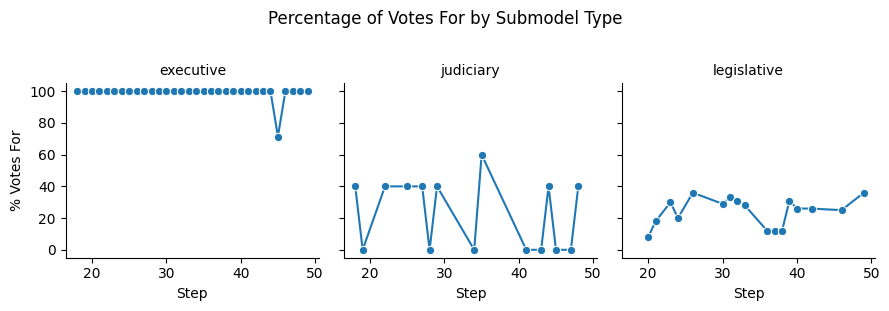

In [4]:
import matplotlib.pyplot as plt
import seaborn as sns


votes_over_time_df["pct_for"] = (
    votes_over_time_df["votes_for"] / votes_over_time_df["total_votes"] * 100
)

g = sns.FacetGrid(votes_over_time_df, col="submodel_type", col_wrap=3, height=3)
g.map_dataframe(sns.lineplot, x="step_no", y="pct_for", marker="o")
g.set_axis_labels("Step", "% Votes For")
g.set_titles("{col_name}")
g.fig.suptitle("Percentage of Votes For by Submodel Type", y=1.02)
plt.tight_layout()
plt.show()